In [1]:
import numpy as np
import matplotlib.pyplot as plt

from powerxai import shapley_value, owen_value, banzhaf_value, upsilon_value
from utils import PLOT_COLORS

# Ranking Discrepancies

In [2]:
def rank_chart(players, method_1_rank, method_2_rank, label_1: str, label_2: str, label_extra: str):
    ### Bump chart
    fig, ax = plt.subplots(figsize=(5, 4))
    for i in range(len(players)):
        rank_changed = method_1_rank[i] != method_2_rank[i]
        color = PLOT_COLORS.GRAY if rank_changed else PLOT_COLORS.BLACK
        ax.plot([0, 1], [method_1_rank[i], method_2_rank[i]], "o-", color=color, alpha=1.0, linewidth=2, markersize=7)
        ax.text(-0.08, method_1_rank[i], players[i], ha="right", va="center", fontsize=9)
        ax.text(1.08, method_2_rank[i], players[i], ha="left", va="center", fontsize=9)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([label_1, label_2], fontsize=11, fontweight="bold")
    ax.set_xlim(-0.45, 1.45)
    ax.invert_yaxis()
    ax.set_yticks(range(1, len(players) + 1))
    ax.set_ylabel("Rank")
    ax.set_title(f"Ranking shift: {label_1} vs {label_2}. {label_extra}")
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    plt.tight_layout()

[ 0.25255604 -0.06470933  0.24607189  0.19564997  0.04736067  0.30635126]
[ 0.16101562 -0.07649482  0.17971404  0.21775786  0.16430716  0.33698065]


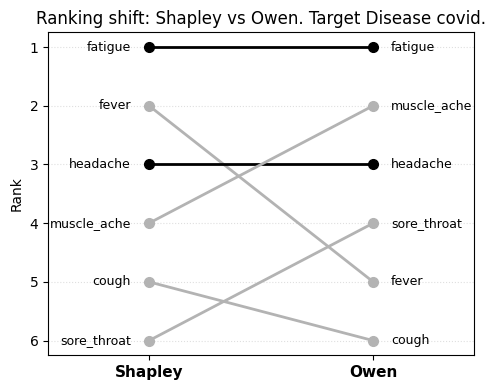

In [4]:
from disease_model import DiseaseClassificationModel

model = DiseaseClassificationModel()
feature_names = model.FEATURE_NAMES
TARGET_CLASS = "covid"
TARGET_CLASS_INDEX = model.CLASS_NAMES.index(TARGET_CLASS)
PROBABILITIES_INDEX = 3
owen_groups = [["fever", "cough", "headache"], ["muscle_ache", "sore_throat", "fatigue"]]

def probability_of_cold(players, coalition_indices):
    symptom_vector = [1 if i in coalition_indices else 0 for i in range(len(feature_names))]
    probabilities = model.classify(symptom_vector, PRINT=False)[PROBABILITIES_INDEX]
    return probabilities[TARGET_CLASS_INDEX]


### Compute influence scores
num_features = len(feature_names)
shapley_scores = np.array([shapley_value(i, feature_names, probability_of_cold) for i in range(num_features)])
owen_scores = np.array([owen_value(i, owen_groups, probability_of_cold) for i in range(num_features)])
print(shapley_scores)
print(owen_scores)
shapley_ranking = np.argsort(np.abs(shapley_scores))[::-1]
owen_ranking = np.argsort(np.abs(owen_scores))[::-1]

# Map each feature to its 1-based rank position
ranks = np.arange(1, num_features + 1)
shapley_rank_by_player = ranks[np.argsort(shapley_ranking)]
banzhaf_rank_by_player = ranks[np.argsort(owen_ranking)]

rank_chart(feature_names, shapley_rank_by_player, banzhaf_rank_by_player, "Shapley", "Owen", f"Target Disease {TARGET_CLASS}.")

### Ranking Discrepancies with Simpler Game

In [5]:
PLAYERS = ["A", "B", "C", "D"]
def game(players, coalition_indices):
    coalition = [PLAYERS[index] for index in coalition_indices]
    if set(coalition) == {PLAYERS[2]}: return 1
    if set(coalition) == {PLAYERS[0], PLAYERS[1]}: return 1
    return 0

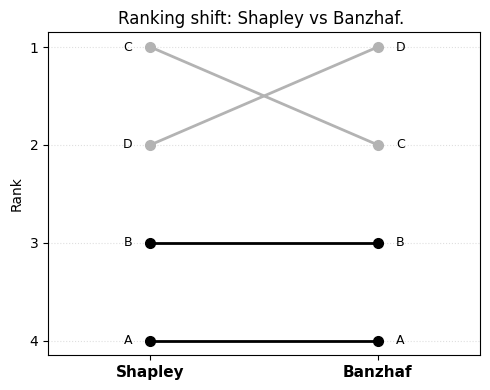

In [6]:
### Compute influence scores
num_players = len(PLAYERS)
shapley_scores = np.array([shapley_value(i, PLAYERS, game) for i in range(num_players)])
banzhaf_scores = np.array([banzhaf_value(i, PLAYERS, game) for i in range(num_players)])
shapley_ranking = np.argsort(np.abs(shapley_scores))[::-1]
banzhaf_ranking = np.argsort(np.abs(banzhaf_scores))[::-1]

# Map each feature to its 1-based rank position
ranks = np.arange(1, num_players + 1)
shapley_rank_by_player = ranks[np.argsort(shapley_ranking)]
banzhaf_rank_by_player = ranks[np.argsort(banzhaf_ranking)]

rank_chart(PLAYERS, shapley_rank_by_player, banzhaf_rank_by_player, "Shapley", "Banzhaf", "")

# When Group Structure Changes Attribution

### Single Player Dimension

Shapley: [0.333, 0.333, 0.333] Owen: [0.25, 0.25, 0.5]


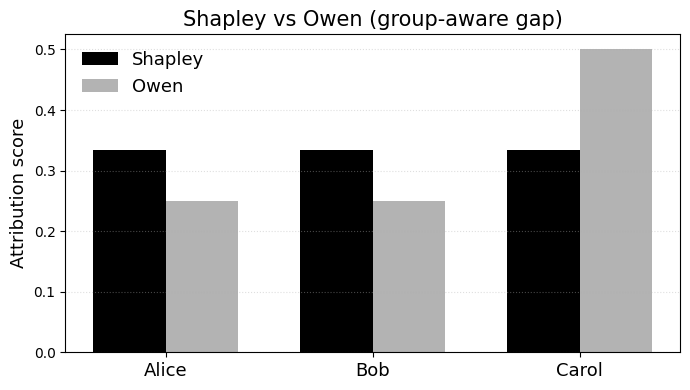

In [29]:
def player_3_valuable(players, coalition_indices):
      set_coalition_indices = frozenset(coalition_indices)
      if not set_coalition_indices: return 0.0
      if set_coalition_indices == frozenset({0}): return 0.0
      if set_coalition_indices == frozenset({1}): return 0.0
      if set_coalition_indices == frozenset({2}): return 0.0
      if set_coalition_indices == frozenset({0, 1}): return 0.0
      if set_coalition_indices == frozenset({0, 2}): return 0.0
      if set_coalition_indices == frozenset({1, 2}): return 0.0
      if set_coalition_indices == frozenset({0, 1, 2}): return 1.0
      raise ValueError(f"Unexpected coalition: {sorted(set_coalition_indices)}")


PLAYERS = ["Alice", "Bob", "Carol"]
GROUPS = [["Alice", "Bob"], ["Carol"]]
shapley = np.array([shapley_value(i, PLAYERS, player_3_valuable) for i in range(3)])
owen = np.array([owen_value(i, GROUPS, player_3_valuable) for i in range(3)])


x, w = np.arange(3), 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w / 2, shapley, w, label="Shapley", color=PLOT_COLORS.BLACK)
ax.bar(x + w / 2, owen, w, label="Owen", color=PLOT_COLORS.GRAY)
ax.set_xticks(x); ax.set_xticklabels([f"{p}" for p in PLAYERS], fontsize=13)
ax.set_ylabel("Attribution score", fontsize=13)
ax.set_title("Shapley vs Owen (group-aware gap)", fontsize=15)
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.legend(frameon=False, fontsize=13)
plt.tight_layout()


print("Shapley:", np.round(shapley, 3).tolist(), "Owen:", np.round(owen, 3).tolist())

### Set Player Dimension

Set-Shapley: [0.5, 0.5]


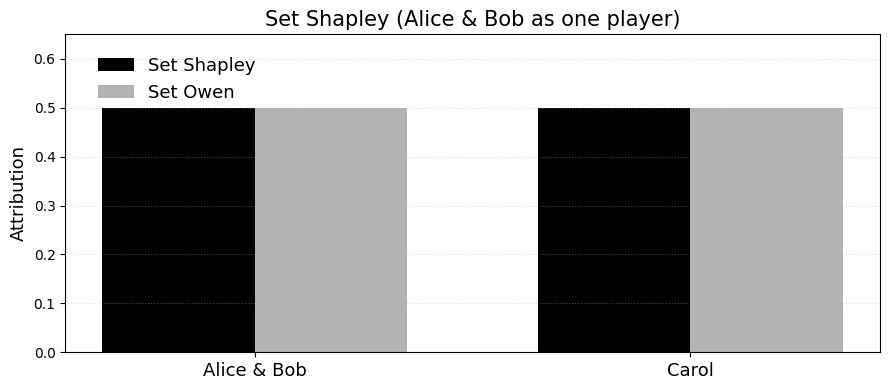

In [31]:
def player_3_valuable_set(players, coalition_indices):
      coalition = frozenset(coalition_indices)
      if not coalition: return 0.0
      if coalition == frozenset({0}): return 0.0
      if coalition == frozenset({1}): return 0.0
      if coalition == frozenset({0, 1}): return 1.0
      raise ValueError(f"Unexpected coalition: {sorted(coalition)}")

SET_PLAYERS = [["Alice & Bob"], ["Carol"]]
set_shapley = np.array([shapley_value(i, SET_PLAYERS, player_3_valuable_set) for i in range(len(SET_PLAYERS))])
set_owen = np.array([owen_value(i, SET_PLAYERS, player_3_valuable_set) for i in range(len(SET_PLAYERS))])

x, w = np.arange(2), 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w / 2, set_shapley, w, label="Set Shapley", color=PLOT_COLORS.BLACK)
ax.bar(x + w / 2, set_shapley, w, label="Set Owen", color=PLOT_COLORS.GRAY)
ax.set_xticks(x)
ax.set_xticklabels([f"{' & '.join(p)}" for p in SET_PLAYERS], fontsize=13)
ax.set_ylabel("Attribution", fontsize=13)
ax.set_title("Set Shapley (Alice & Bob as one player)", fontsize=15)
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.set_ylim(0, max(set_shapley) * 1.30)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.02, 0.98), fontsize=13)
plt.tight_layout()

print("Set-Shapley:", np.round(set_shapley, 3).tolist())

Upsilon: [0.0, 0.0, 1.0]


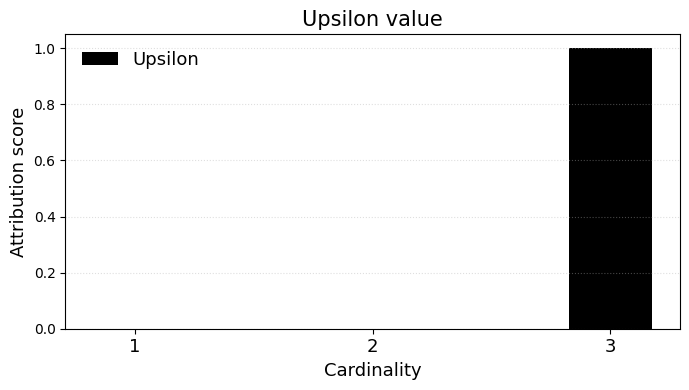

In [35]:
def player_3_valuable(players, coalition_indices):
      set_coalition_indices = frozenset(coalition_indices)
      if not set_coalition_indices: return 0.0
      if set_coalition_indices == frozenset({0}): return 0.0
      if set_coalition_indices == frozenset({1}): return 0.0
      if set_coalition_indices == frozenset({2}): return 0.0
      if set_coalition_indices == frozenset({0, 1}): return 0.0
      if set_coalition_indices == frozenset({0, 2}): return 0.0
      if set_coalition_indices == frozenset({1, 2}): return 0.0
      if set_coalition_indices == frozenset({0, 1, 2}): return 1.0
      raise ValueError(f"Unexpected coalition: {sorted(set_coalition_indices)}")


PLAYERS = ["Alice", "Bob", "Carol"]
upsilon = np.array([upsilon_value(cardinality=i+1, players=PLAYERS, value_function=player_3_valuable) for i in range(3)])

x = np.arange(3)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x, upsilon, w, label="Upsilon", color=PLOT_COLORS.BLACK)
ax.set_xticks(x); ax.set_xticklabels(["1", "2", "3"], fontsize=13)
ax.set_xlabel("Cardinality", fontsize=13)
ax.set_ylabel("Attribution score", fontsize=13)
ax.set_title("Upsilon value", fontsize=15)
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.legend(frameon=False, fontsize=13)
plt.tight_layout()


print("Upsilon:", np.round(upsilon, 3).tolist())